## Imports

In [1]:
from astroquery.sdss import SDSS
from astropy.io import fits

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

import datetime
import os
import re
import joblib

In [2]:
data_dir = "../astro_sandbox/data/starspectra"
data_output_dir = "../astro_sandbox/data_output/starspectra"

## Load Data (Local)

Once the data is handy - we can just load the metadata (pandas df)   
and the fits file containing spectrum information in the fits_data object

In [3]:
df = pd.read_csv(f"{data_dir}/BalancedStarSpectra500_Winnie.csv")
df['major_type'] = df['subclass'].str.extract(r'^([OBAFGKM])')
# df.info()

In [4]:
df.shape

(3192, 40)

In [5]:
# df.head(1)

Spectrum could be different length - we try to have them in the same wavelength grid  
https://www.sdss4.org/dr17/spectro/spectro_basics/  
Based on the wavelngth coverage mentioned on the SDSS -  
Wave Min and Wave Max is supposed to be 3800-9200 (Angstroms) for SDSS  
 and its 3650-10400 for BOSS - we set our constants to the latter as they cover wider range

Also native resolution of SDSS seems to be 2.53-3.60 Angstroms  
1500 Angstroms / 3800 = 2.53 Angstroms  
9000 Angstroms / 2500 = 3.60 Angstroms  

the bins are selected to reduce the resolution a bit (but we can have more bins upto even 5000 as we'll just reach 1.35 Angtroms)


In [6]:
SPECTRAL_CLASSES = {'O', 'B', 'A', 'F', 'G', 'K', 'M'}
WAVE_MIN, WAVE_MAX, N_BINS = 3800, 9200, 3600 # Number of bins = (9200-3800) / 1.5 (desired resolution) = 3600
# WAVE_MIN, WAVE_MAX, N_BINS = 3650, 10400, 2000
COMMON_WAVE = np.linspace(WAVE_MIN, WAVE_MAX, N_BINS)

def load_local_spectrum(fits_path):
    try:
        with fits.open(fits_path) as hdul:
            data = hdul[1].data
            wavelength = 10**data['loglam'] # Converting wavelengths to linear scale
            flux = data['flux'] 

            # valid_wave = wavelength[flux > 0]
            # wv_min = max(WAVE_MIN, valid_wave.min())
            # wv_max = min(WAVE_MAX, valid_wave.max())
            # COMMON_WAVE = np.linspace(wv_min, wv_max, N_BINS)

            mask = flux > 0
            if not np.any(mask):
                return None

            interp_flux = interp1d(wavelength[mask], flux[mask], bounds_error=False, fill_value=0.0) #Estimating flux
            flux_resampled = interp_flux(COMMON_WAVE) #resample flux
            # median = np.median(flux_resampled[np.nonzero(flux_resampled)])
            median = np.median(flux_resampled[flux_resampled > 0])

            return flux_resampled / median if median else None #median normalization
    except Exception as e:
        print(f"Error loading {fits_path}: {e}")
        return None

In [7]:
fits_data = {}
for _, row in df.iterrows():
    plate, mjd, fiberID, subclass, majorclass = row['plate'], row['mjd'], row['fiberID'], row['subclass'], row['major_type']
    fits_path = f"{data_dir}/raw_fits500/spec-{plate}-{mjd}-{fiberID}.fits"
    spectrum = load_local_spectrum(fits_path)
    if spectrum is not None:
        fits_data[(plate, mjd, fiberID)] = (spectrum, subclass, majorclass)
        # plot_spectrum(COMMON_WAVE, spectrum, f"{majorclass}-{subclass}", plate, mjd, fiberID)

Error loading ../astro_sandbox/data/starspectra/raw_fits500/spec-3853-55268-212.fits: [Errno 2] No such file or directory: '../astro_sandbox/data/starspectra/raw_fits500/spec-3853-55268-212.fits'


In [8]:
len(fits_data.keys())

3191

## Standard Normalization Techniques

Here we explore well known normalization techniques

### Min Max Scaling

Linearly rescales values using minimum and maximum values to the [0, 1] range.  
(flux - min(flux)) / (max(flux) - min(flux) + 1e-8)

In [9]:
def normalize_min_max(spectra):
    spectra_min = spectra.min(axis=1, keepdims=True)
    spectra_max = spectra.max(axis=1, keepdims=True)
    return (spectra - spectra_min) / (spectra_max - spectra_min + 1e-8)

### Z Scaling

Centers data at zero mean, unit variance   
(flux - mean(flux)) / (std(flux) + 1e-8)



In [10]:
def normalize_z_score(spectra):
    mean = spectra.mean(axis=1, keepdims=True)
    std = spectra.std(axis=1, keepdims=True)
    return (spectra - mean) / (std + 1e-8)

### AUC norm

Normalizes based on total energy (integrated flux)  
flux / (∫ flux dλ + 1e-8)

In [11]:
def normalize_auc(spectra):
    area = np.trapz(spectra, COMMON_WAVE, axis=1).reshape(-1, 1)
    return spectra / (area + 1e-8)


### Max Norm

In [12]:
def normalize_max(spectrum):
    return spectrum / (np.max(spectrum) + 1e-8)



### L2 Norm

In [13]:
def normalize_l2(spectrum):
    norm = np.linalg.norm(spectrum)
    return spectrum / (norm + 1e-8)


### IQR norm

In [14]:
def normalize_robust(spectrum):
    median = np.median(spectrum)
    iqr = np.percentile(spectrum, 75) - np.percentile(spectrum, 25)
    return (spectrum - median) / (iqr + 1e-8)


### Log Norm

In [15]:
def normalize_log(spectra):
    return np.log1p(spectra)  # log(1 + x)



### Quantile Norm

In [16]:
def normalize_quantile(spectra):
    sorted_X = np.sort(spectra, axis=1)
    ranks = np.argsort(np.argsort(spectra, axis=1), axis=1)
    avg_dist = np.mean(sorted_X, axis=0)
    return avg_dist[ranks]

### Evaluate

#### Spectra Normalization

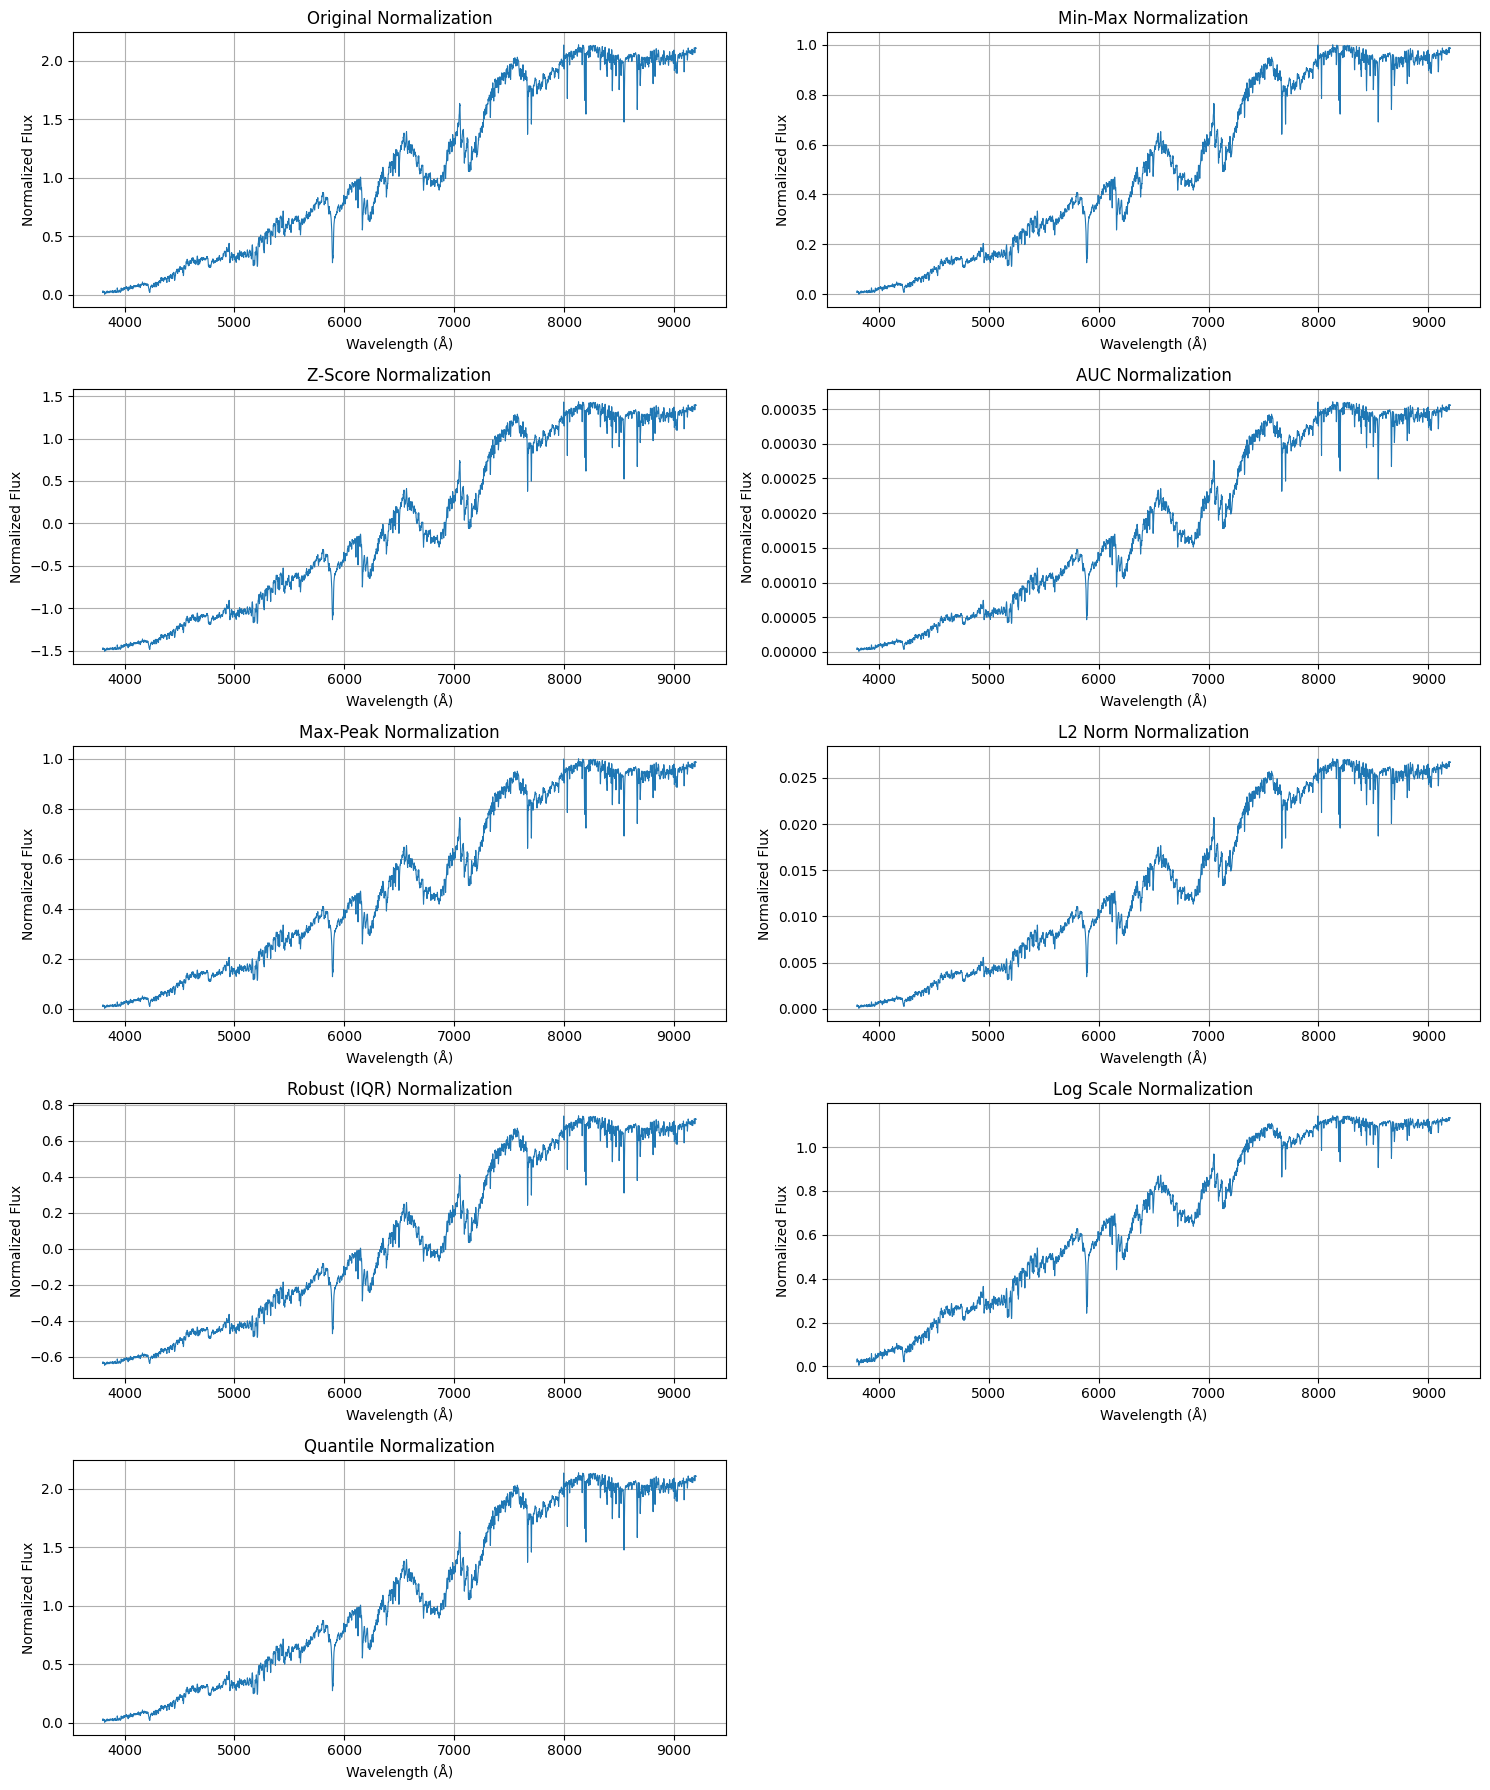

In [17]:
#11060, 58523, 493#4050, 55599, 14#3794, 55241, 954#1259, 52931, 638
spectrum, subclass, majorclass = fits_data[(11060, 58523, 493)]
X = np.array([spectrum])

methods = {
    "Original": X[0],
    "Min-Max": normalize_min_max(X)[0],
    "Z-Score": normalize_z_score(X)[0],
    "AUC": normalize_auc(X)[0],
    "Max-Peak": normalize_max(X)[0],
    "L2 Norm": normalize_l2(X)[0],
    "Robust (IQR)": normalize_robust(X)[0],
    "Log Scale": normalize_log(X)[0],
    "Quantile": normalize_quantile(X)[0]
}

plt.figure(figsize=(15, 18))
for i, (label, norm_flux) in enumerate(methods.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    plt.plot(COMMON_WAVE, norm_flux, lw=0.8)
    plt.title(f"{label} Normalization")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    # plt.savefig(f"sample_norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Feature Normalization

In [18]:
X_all = np.array([s for (s, _, _) in fits_data.values()]) 

# X_norms = {
#     "Original": X_all,
#     "Min-Max": normalize_min_max(X_all),
#     "Z-Score": normalize_z_score(X_all),
#     "AUC": normalize_auc(X_all),
#     "Max-Peak": normalize_max(X_all),
#     "L2 Norm": normalize_l2(X_all),
#     "Robust (IQR)": normalize_robust(X_all),
#     "Log Scale": normalize_log(X_all),
#     "Quantile": normalize_quantile(X_all)
# }

In [19]:
def normalize_min_max_global(X):
    min_vals = X.min(axis=0, keepdims=True)
    max_vals = X.max(axis=0, keepdims=True)
    return (X - min_vals) / (max_vals - min_vals + 1e-8)

def normalize_z_score_global(X):
    mean_vals = X.mean(axis=0, keepdims=True)
    std_vals = X.std(axis=0, keepdims=True)
    return (X - mean_vals) / (std_vals + 1e-8)

def normalize_auc_global(X):
    # aucs = np.trapz(X, COMMON_WAVE, axis=1, keepdims=True)
    aucs = np.trapz(X, COMMON_WAVE, axis=1).reshape(-1, 1)
    return X / (aucs + 1e-8)

def normalize_max_global(X):
    max_vals = X.max(axis=1, keepdims=True)
    return X / (max_vals + 1e-8)

def normalize_l2_global(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + 1e-8)

def normalize_robust_global(X):
    median_vals = np.median(X, axis=0, keepdims=True)
    iqr_vals = np.percentile(X, 75, axis=0, keepdims=True) - np.percentile(X, 25, axis=0, keepdims=True)
    return (X - median_vals) / (iqr_vals + 1e-8)

def normalize_log_global(X):
    return np.log1p(X)  # log(1 + x)

def normalize_quantile_global(X):
    sorted_X = np.sort(X, axis=0)
    ranks = np.argsort(np.argsort(X, axis=0), axis=0)
    avg_dist = np.mean(sorted_X, axis=0)
    return avg_dist[ranks]

# Apply all methods
X_norms = {
    "Original": X_all,
    "Min-Max": normalize_min_max_global(X_all),
    "Z-Score": normalize_z_score_global(X_all),
    "AUC": normalize_auc_global(X_all),
    "Max-Peak": normalize_max_global(X_all),
    "L2 Norm": normalize_l2_global(X_all),
    "Robust (IQR)": normalize_robust_global(X_all),
    "Log Scale": normalize_log_global(X_all),
    "Quantile": normalize_quantile_global(X_all)
}

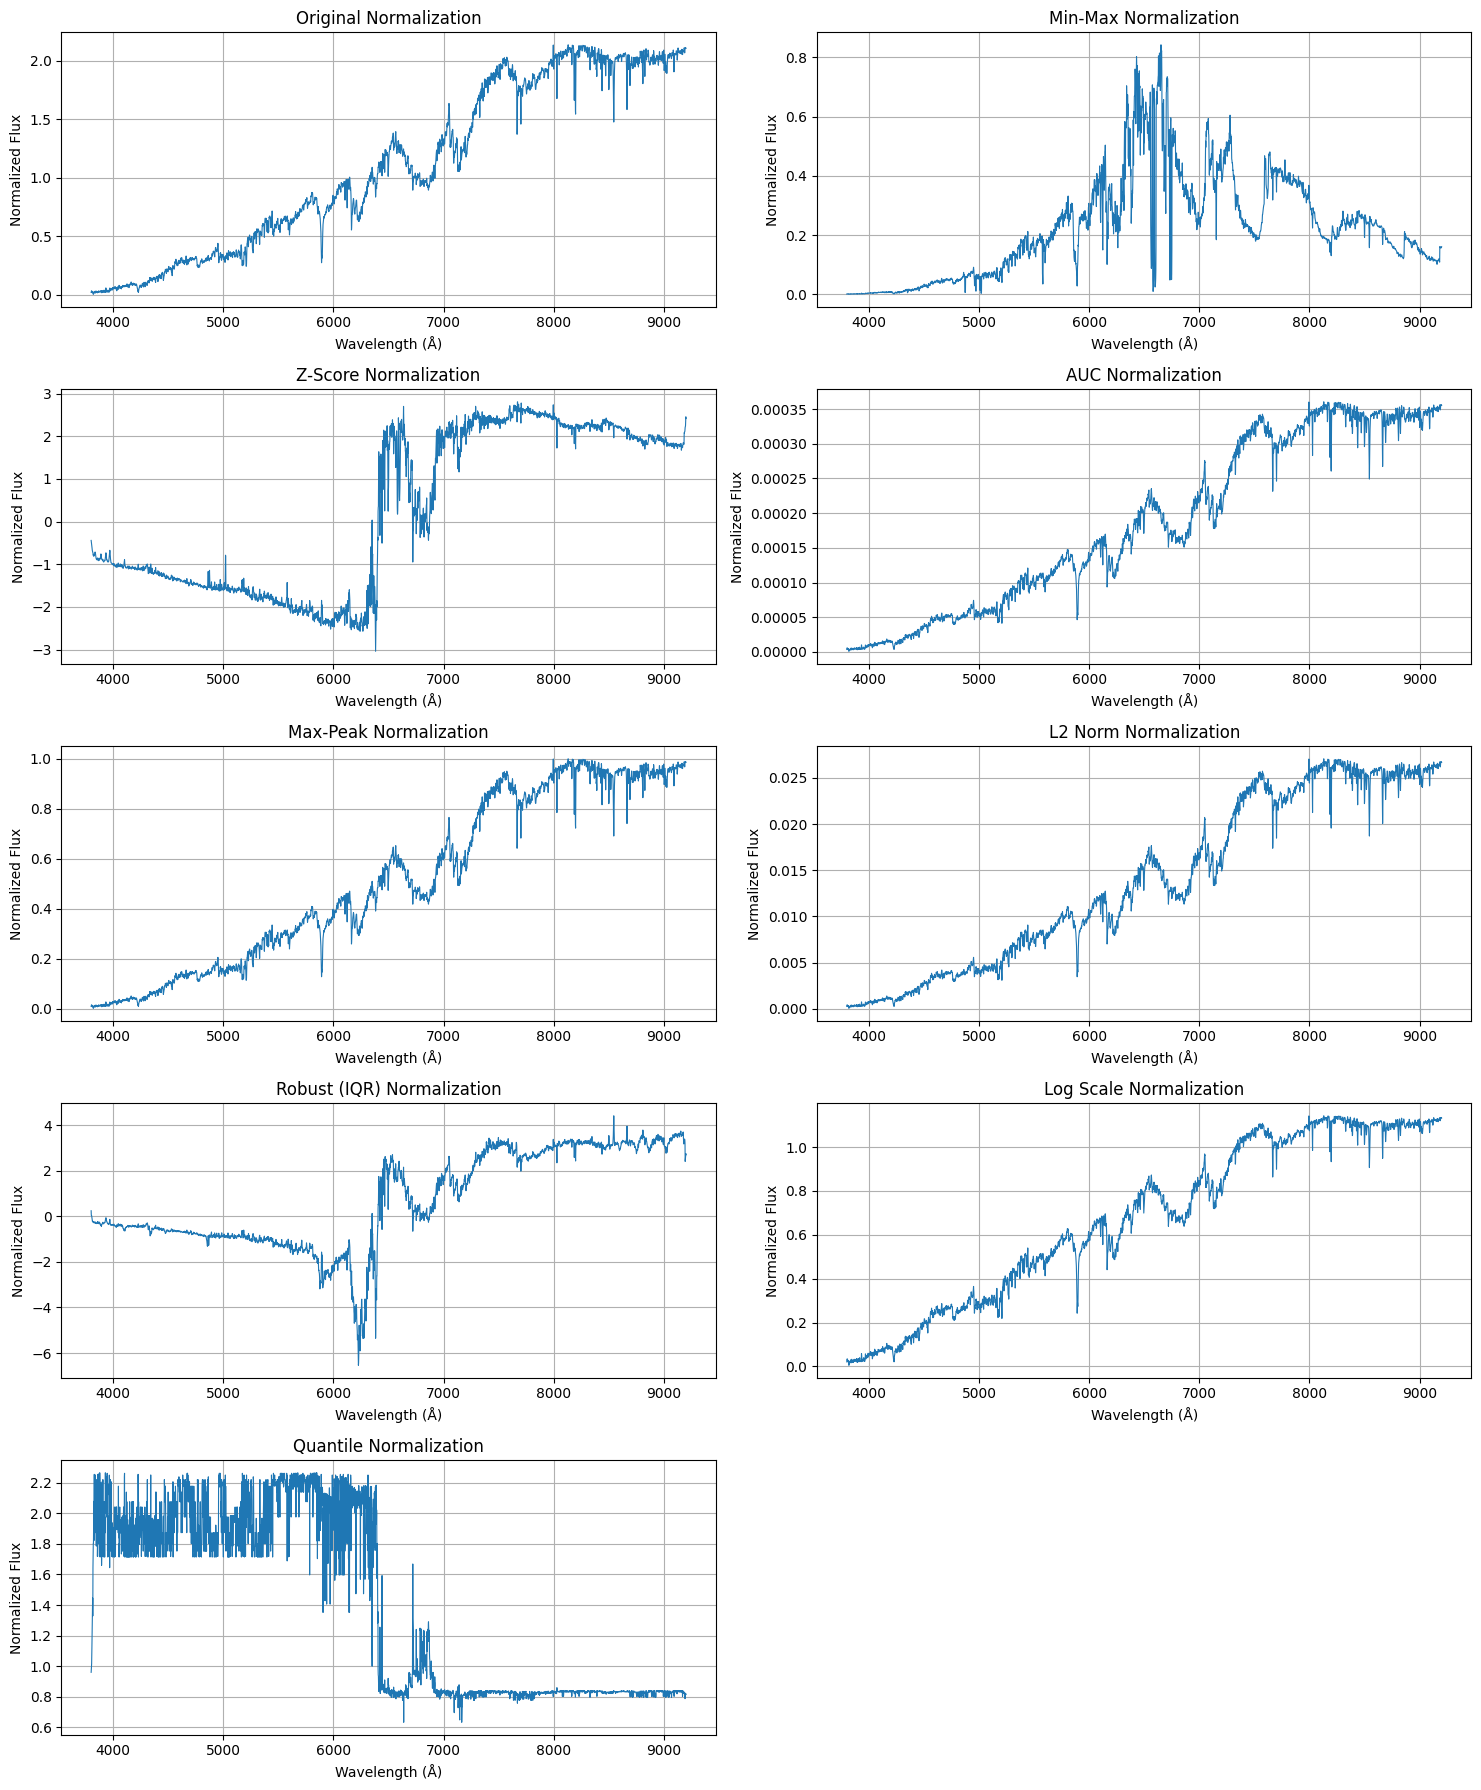

In [20]:
target_key = (11060, 58523, 493)
target_index = list(fits_data.keys()).index(target_key)

plt.figure(figsize=(15, 18))
for i, (label, Xn) in enumerate(X_norms.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    # plt.plot(COMMON_WAVE, norm_flux, lw=0.8)
    plt.plot(COMMON_WAVE, Xn[target_index], lw=0.8)
    plt.title(f"{label} Normalization")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    # plt.savefig(f"norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


##### Distribution

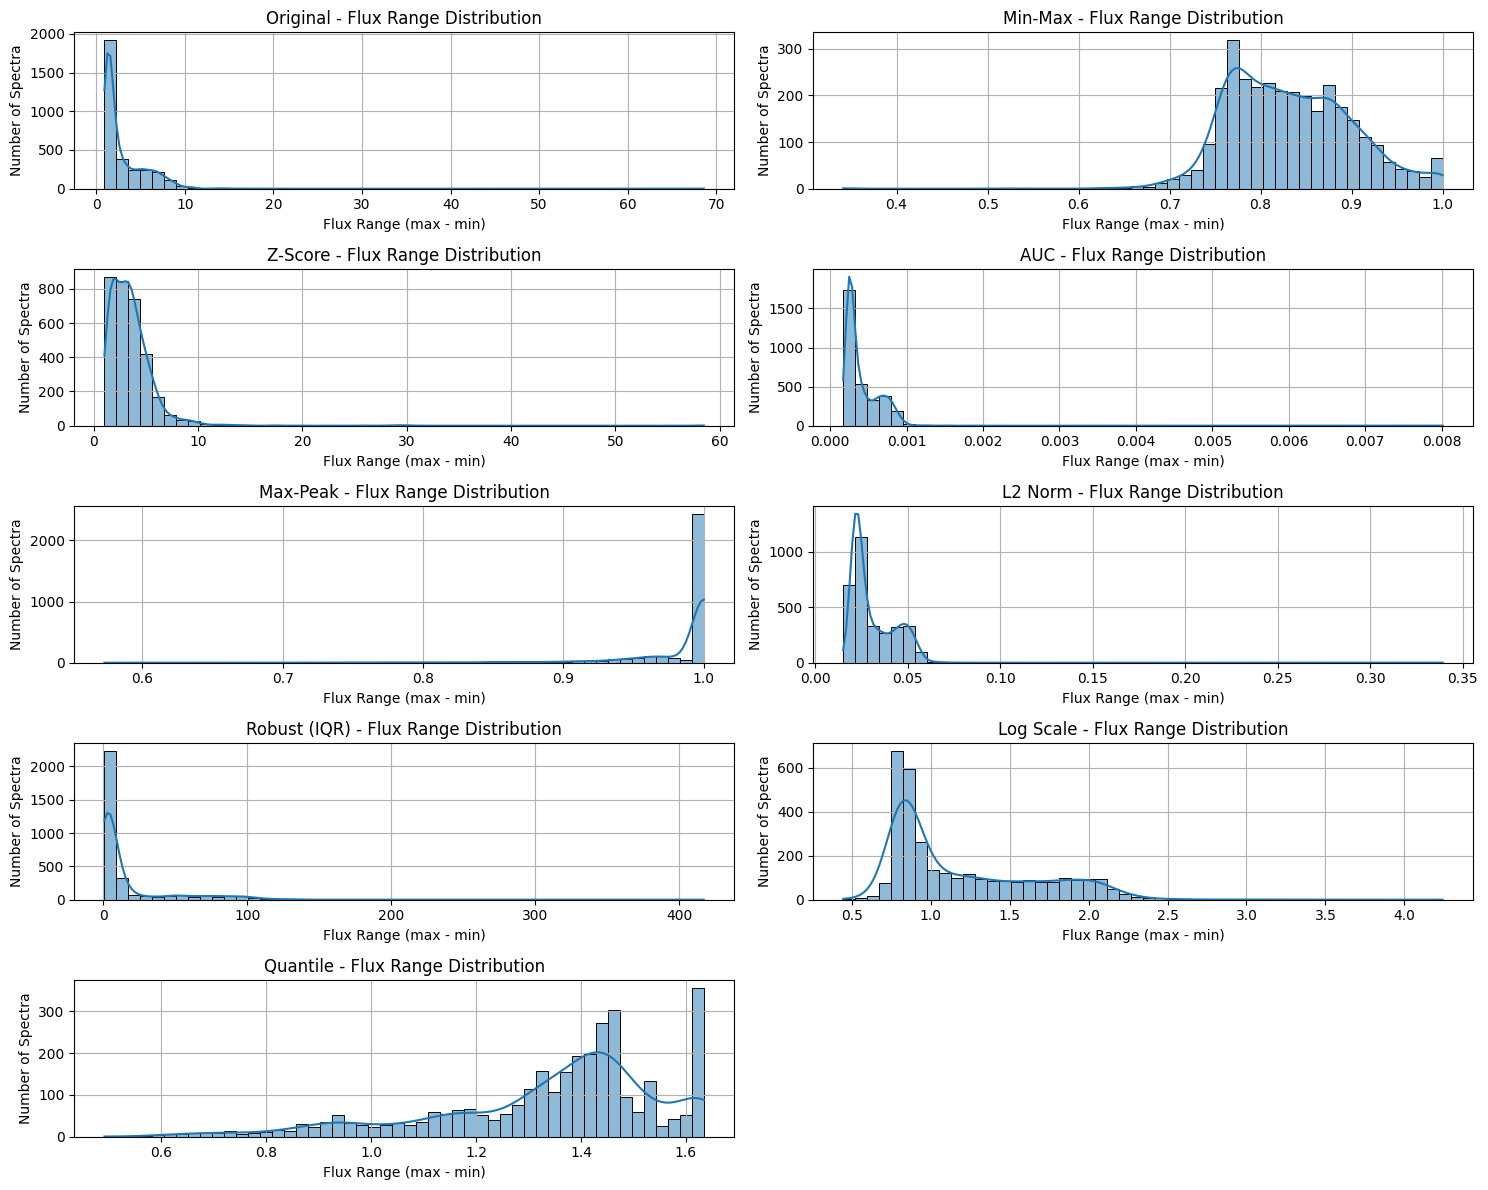

In [21]:
def compute_flux_stats(spectra):
    return pd.DataFrame({
        'min_flux': np.min(spectra, axis=1),
        'max_flux': np.max(spectra, axis=1),
        'mean_flux': np.mean(spectra, axis=1),
        'median_flux': np.median(spectra, axis=1),
        'range_flux': np.ptp(spectra, axis=1),  # max - min
    })

# Compute stats for each normalization method
stats_by_method = {label: compute_flux_stats(Xn) for label, Xn in X_norms.items()}

# Plot distribution of flux ranges for each
plt.figure(figsize=(15, 12))
for i, (label, stats_df) in enumerate(stats_by_method.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    sns.histplot(stats_df['range_flux'], bins=50, kde=True)
    plt.title(f"{label} - Flux Range Distribution")
    plt.xlabel("Flux Range (max - min)")
    plt.ylabel("Number of Spectra")
    # plt.savefig(f"dist_norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


## Continuum Normalization Analysis

#### Savitzky-Golay Filtering
Smoothing Filter, keeps general shape (bypasses narrow filters and can oversmooth broad features)  
no external data required, good for good data (high SNR data), not good for noise data    

In [22]:
from scipy.signal import savgol_filter

def continuum_savgol(flux, window=None, poly=3, clip_percentile=90):
    if window is None: window = min(151, len(flux) // 10 | 1) # dynamically find the window based on flux
    if window % 2 == 0: window += 1  # odd window (req by savgol filter)

    # Mask absorption lines (keep only upper X% flux values)
    threshold = np.percentile(flux, clip_percentile)
    mask = flux > threshold
    # Interpolate over masked points for smoother baseline
    interp_flux = np.copy(flux)
    interp_flux[~mask] = np.interp(np.flatnonzero(~mask), np.flatnonzero(mask), flux[mask])

    continuum = savgol_filter(interp_flux, window_length=window, polyorder=poly, mode='interp')
    continuum = np.clip(continuum, 1e-5, None) #Avoid division by very very small numbers so its not inf and ensure its not 0 or -ve
    return flux / continuum, continuum



#### Spline fit
Through a 'pseudo continuum' of high flux points  
adapts to shape of spectrum   
good for moderate and high res, not so good for noise data (peak noises)


In [23]:
from scipy.interpolate import UnivariateSpline

def continuum_spline(wave, flux, high_percentile=95, s_factor=1e-4):
    mask = np.zeros_like(flux, dtype=bool)
    # n_bins = 5
    # bins = np.linspace(wave.min(), wave.max(), n_bins+1)
    n_bins = max(10, len(flux) // 300)
    bins = np.linspace(wave.min(), wave.max(), n_bins + 1)

    for i in range(n_bins):
        bin_mask = (wave >= bins[i]) & (wave < bins[i+1])
        bin_flux = flux[bin_mask]
        if len(bin_flux) == 0:
            continue
        threshold = np.percentile(bin_flux, high_percentile)
        mask[bin_mask] |= (flux[bin_mask] > threshold)

    if np.sum(mask) < 10:
        raise ValueError("Too few points to fit spline")
    
    s = s_factor * (wave.max() - wave.min()) * len(wave)
    spline = UnivariateSpline(wave[mask], flux[mask], s=s)
    continuum = spline(wave)
    continuum = np.clip(continuum, 1e-4, None)
    return flux / continuum, continuum


Uses savgol to smooth out the continuum for removing noise and small features, does a sigma clipping to get continuum points and further separates peaks from troughs

In [24]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter, medfilt

def continuum_spline_wsavgol(wave, flux, smooth_window=None, sigma=2.5, s_factor=1e-4, top_n_per_bin=10, n_bins=15, verbose=False):
    if smooth_window is None: smooth_window = min(151, len(flux) // 10 | 1)
    if smooth_window % 2 == 0: smooth_window += 1

    # Step 1: Initial smoothing
    init_smooth = medfilt(flux, kernel_size=15)
    smoothed = savgol_filter(init_smooth, window_length=smooth_window, polyorder=3)

    # Step 2: Sigma clipping
    mask = np.ones_like(flux, dtype=bool)
    for _ in range(5):
        residual = flux[mask] - smoothed[mask]
        mad = np.median(np.abs(residual - np.median(residual)))
        if mad < 1e-10:
            break
        std = 1.4826 * mad
        mask[mask] = np.abs(residual) < sigma * std
        smoothed = savgol_filter(flux * mask, window_length=smooth_window, polyorder=3)

    # Step 3: Always get points from each bin
    bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
    cont_mask = np.zeros_like(flux, dtype=bool)

    for i in range(n_bins):
        in_bin = (wave >= bins[i]) & (wave < bins[i + 1])
        idx = np.where(in_bin & mask)[0]
        if len(idx) == 0:
            idx = np.where(in_bin)[0]
        if len(idx) > 0:
            top_idx = idx[np.argsort(flux[idx])[-min(top_n_per_bin, len(idx)):]]
            cont_mask[top_idx] = True

    # Step 4: Fit spline to selected points
    wave_scaled = (wave - wave.mean()) / wave.std()
    s = s_factor * len(wave) * np.median(flux)**2
    spline = UnivariateSpline(wave_scaled[cont_mask], flux[cont_mask], s=s)
    continuum = spline(wave_scaled)
    continuum = np.clip(continuum, 1e-5, None)
    norm = flux / continuum
    norm = np.clip(norm, 0, 10)

    if verbose:
        print(f"Spline fit with {np.sum(cont_mask)} points (no fallback). s={s:.2e}")

    return norm, continuum


#### Polynomial Fit
Low degree fit, so, good for low res spectra  
could be underfitting / overfitting

In [25]:
def continuum_polynomial(wave, flux, deg=5, clip_percentile=90):

    wave_scaled = (wave - wave.mean()) / wave.std()

    threshold = np.percentile(flux, clip_percentile)
    mask = flux > threshold

    coeffs = np.polyfit(wave_scaled[mask], flux[mask], deg)
    continuum = np.polyval(coeffs, wave_scaled)
    continuum = np.clip(continuum, 1e-5, None)

    return flux / continuum, continuum



In [26]:
from scipy.signal import medfilt

def continuum_polynomial_weighted(wave, flux, deg=4, high_percentile=90, smooth=True):
    wave_scaled = (wave - wave.mean()) / wave.std()

    if smooth:
        flux_for_weights = medfilt(flux, kernel_size=5)
    else:
        flux_for_weights = flux

    threshold = np.percentile(flux_for_weights, high_percentile)
    weights = np.clip(flux_for_weights / threshold, 0, 1)

    coeffs = np.polyfit(wave_scaled, flux, deg=deg, w=weights)
    continuum = np.polyval(coeffs, wave_scaled)
    continuum = np.clip(continuum, 1e-4, None)

    return flux / continuum, continuum


### Auto

In [27]:
# def score_method(cont):
#     smoothed = savgol_filter(cont, 101, 3)
#     smoothness = np.std(cont - smoothed)
#     flatness = np.abs(np.median(cont - 1.0))
#     return smoothness + 0.5 * flatness  # Weight toward smooth + ~1

def score_method(norm, cont):
    smoothed = savgol_filter(cont, 101, 3)
    smoothness = np.std(cont - smoothed)
    flatness = np.abs(np.median(norm) - 1.0)
    clip_penalty = np.mean((norm > 5) | (norm < 0.2))
    curvature = np.std(np.gradient(cont))
    score = (
        1.0 * smoothness +
        0.5 * flatness +
        2.0 * clip_penalty +
        0.3 * curvature
    )
    return score

def auto_continuum_normalize(wave, flux, verbose=False, methods=None):
    if methods is None:
        methods = [
            "spline_wsavgol",
            "polynomial_weighted",
            "savgol"
        ]

    results = []

    for method in methods:
        try:
            if method == "spline_wsavgol":
                norm, cont = continuum_spline_wsavgol(wave, flux)
            elif method == "polynomial_weighted":
                norm, cont = continuum_polynomial_weighted(wave, flux)
            elif method == "savgol":
                cont = savgol_filter(flux, window_length=151, polyorder=3, mode='interp')
                cont = np.clip(cont, 1e-5, None)
                norm = flux / cont
            else:
                continue  # Unknown method

            results.append((method, norm, cont))
            if verbose:
                print(f"{method} succeeded")

        except Exception as e:
            if verbose:
                print(f"{method} failed: {e}")

    if not results:
        raise RuntimeError("All continuum normalization methods failed.")

    

    scored = [(method, norm, cont, score_method(norm, cont)) for method, norm, cont in results]
    best_method, best_norm, best_cont, best_score = min(scored, key=lambda x: x[3])

    if verbose:
        print("Tried methods (with scores):")
        for method, _, _, score in scored:
            print(f" - {method}: {score:.4f}")
        print(f"Selected '{best_method}' with score {best_score:.4f}")

    return best_norm, best_cont, best_method


### Evaluate

In [38]:
fits_data.keys()

dict_keys([(1259, 52931, 638), (3794, 55241, 954), (7456, 56727, 193), (7456, 56727, 111), (4050, 55599, 14), (7456, 56727, 730), (4021, 55620, 326), (293, 51689, 508), (7253, 56598, 650), (7253, 56598, 736), (3771, 55544, 416), (2057, 53816, 296), (2057, 53816, 616), (3781, 55243, 40), (367, 51997, 564), (7302, 57012, 206), (2053, 53446, 591), (6986, 56717, 437), (2383, 53800, 577), (4013, 55629, 836), (4027, 55629, 36), (668, 52162, 290), (2305, 54414, 474), (3307, 54970, 70), (2867, 54479, 238), (2877, 54523, 171), (2926, 54625, 572), (3133, 54789, 587), (487, 51943, 45), (3295, 54924, 235), (487, 51943, 219), (528, 52022, 215), (2864, 54467, 474), (2849, 54454, 565), (2305, 54414, 251), (3145, 54801, 452), (4035, 55383, 360), (1960, 53289, 535), (3131, 54731, 50), (3130, 54740, 510), (7333, 56686, 29), (394, 51913, 300), (8297, 57416, 962), (3003, 54845, 381), (3003, 54845, 79), (3321, 54924, 503), (3305, 54945, 571), (749, 52226, 386), (2888, 54529, 306), (4743, 55645, 784), (3833

Spline fit with 150 points (no fallback). s=3.60e-01
spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.0076
 - polynomial_weighted: 0.0049
 - savgol: 0.0096
Selected 'polynomial_weighted' with score 0.0049
Spline fit with 150 points (no fallback). s=3.60e-01
spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.1238
 - polynomial_weighted: 0.1962
 - savgol: 0.0079
Selected 'savgol' with score 0.0079
Spline fit with 150 points (no fallback). s=3.60e-01
spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.0046
 - polynomial_weighted: 0.0543
 - savgol: 0.0151
Selected 'spline_wsavgol' with score 0.0046
Spline fit with 150 points (no fallback). s=3.60e-01
spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.0087
 - p

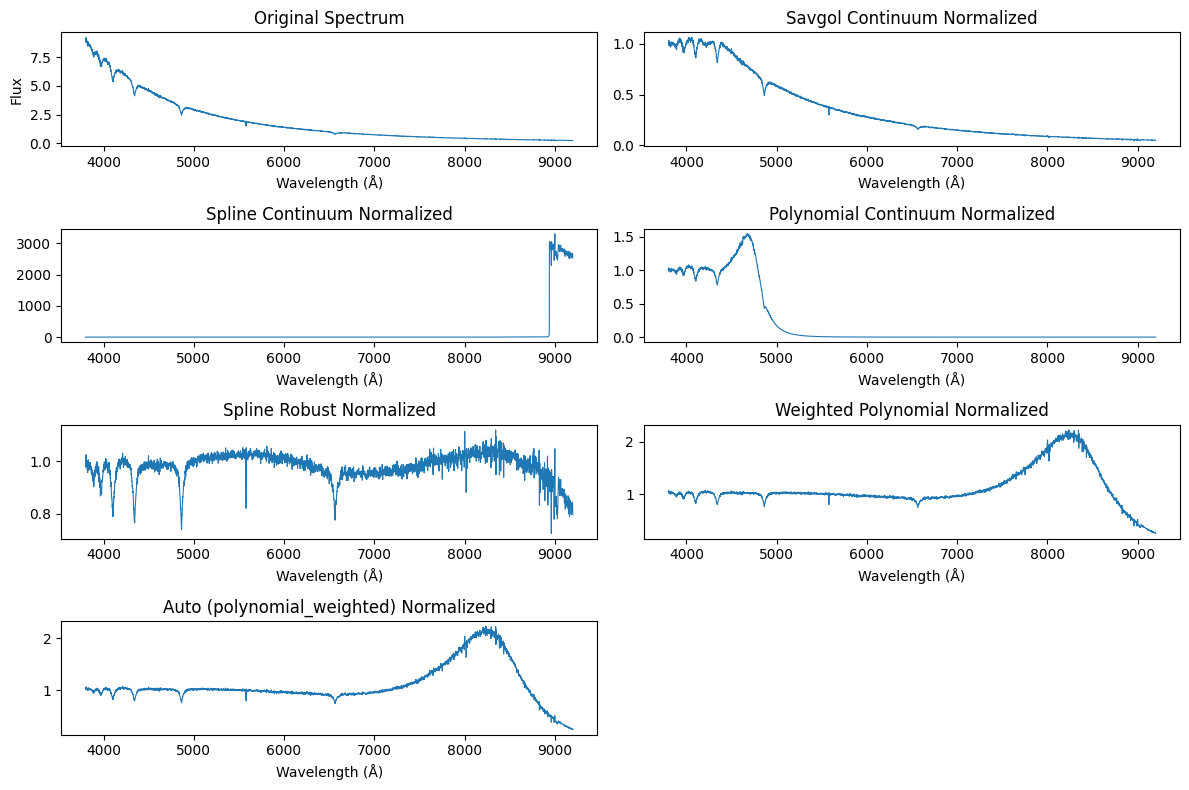

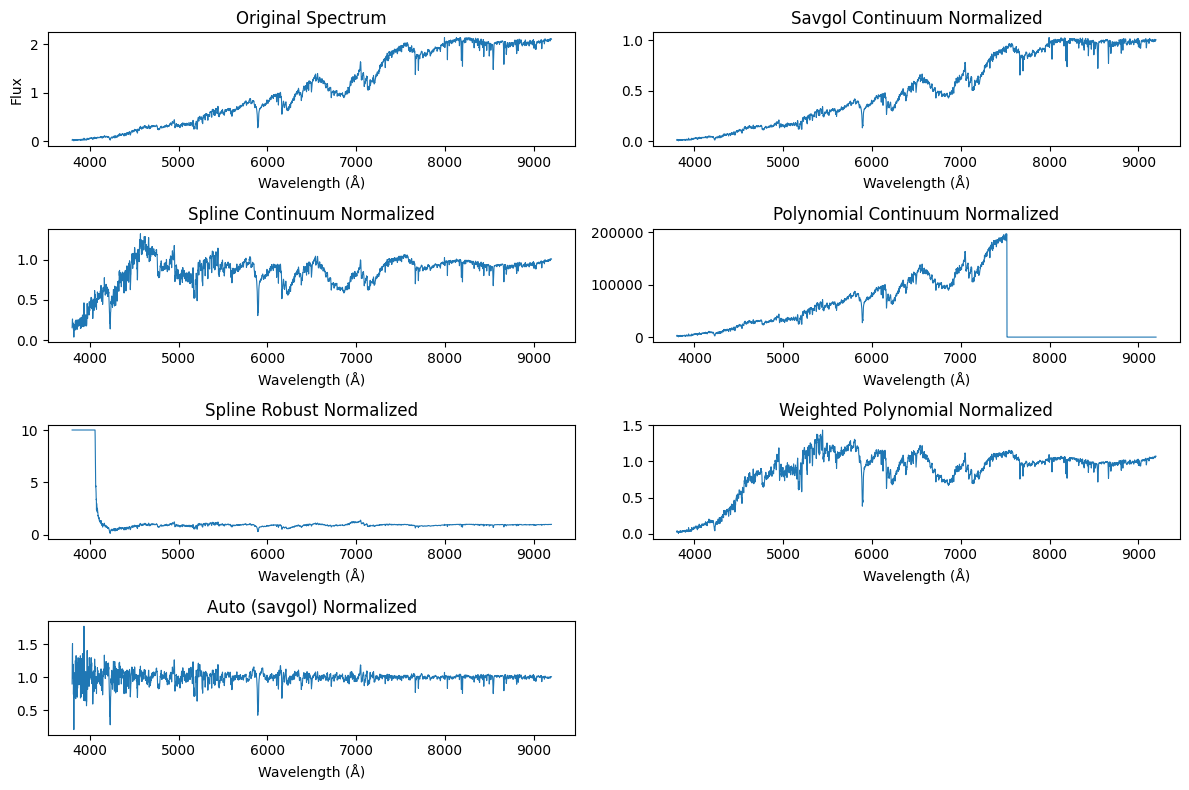

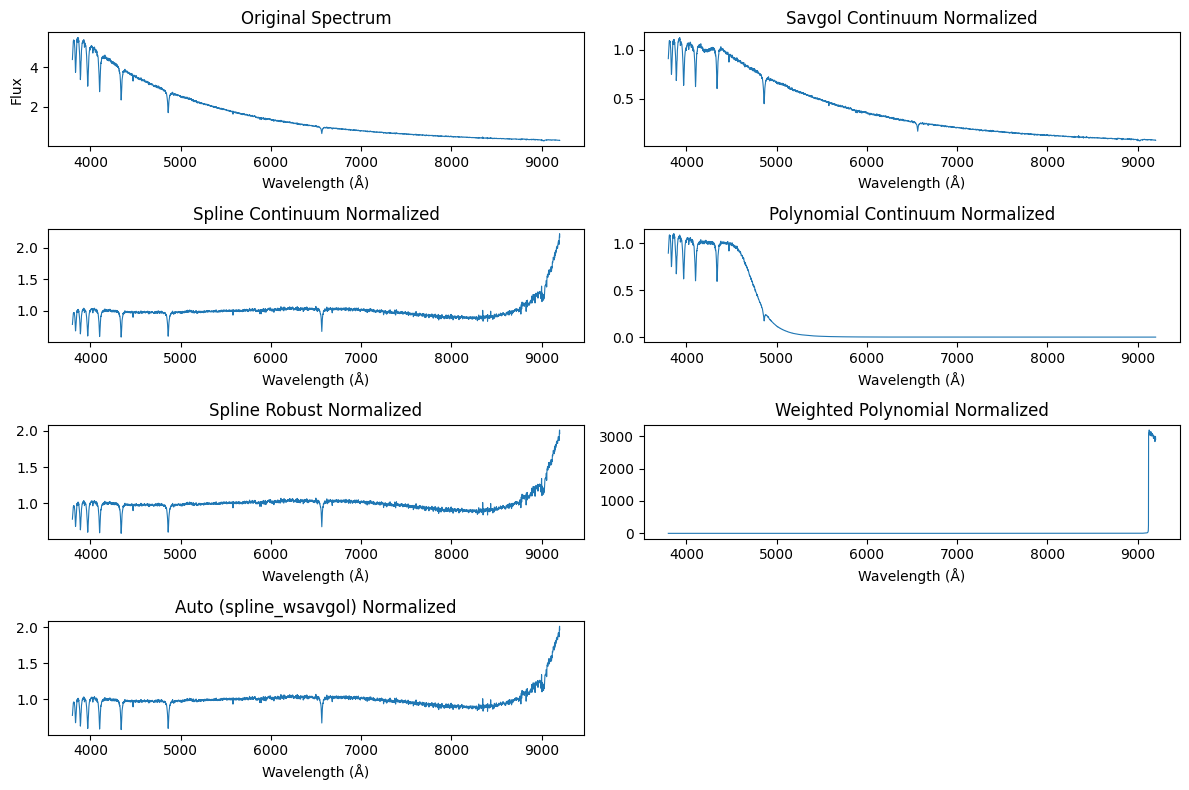

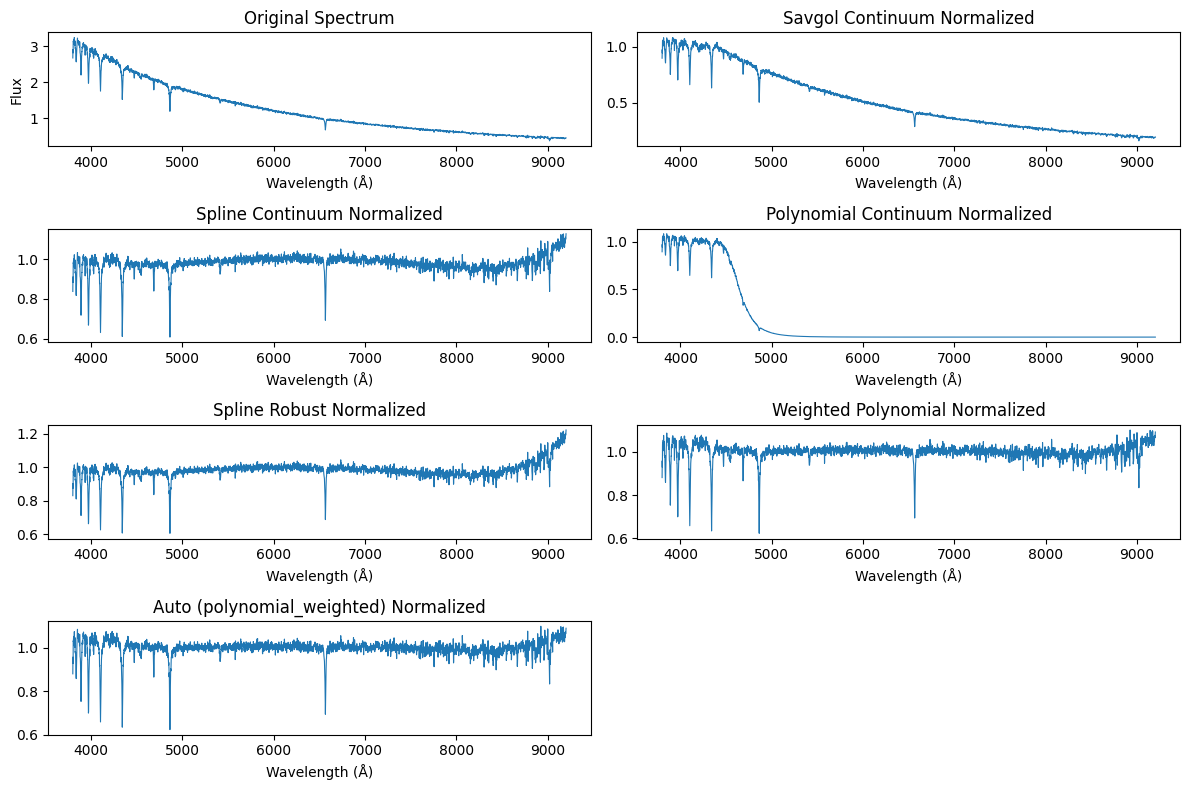

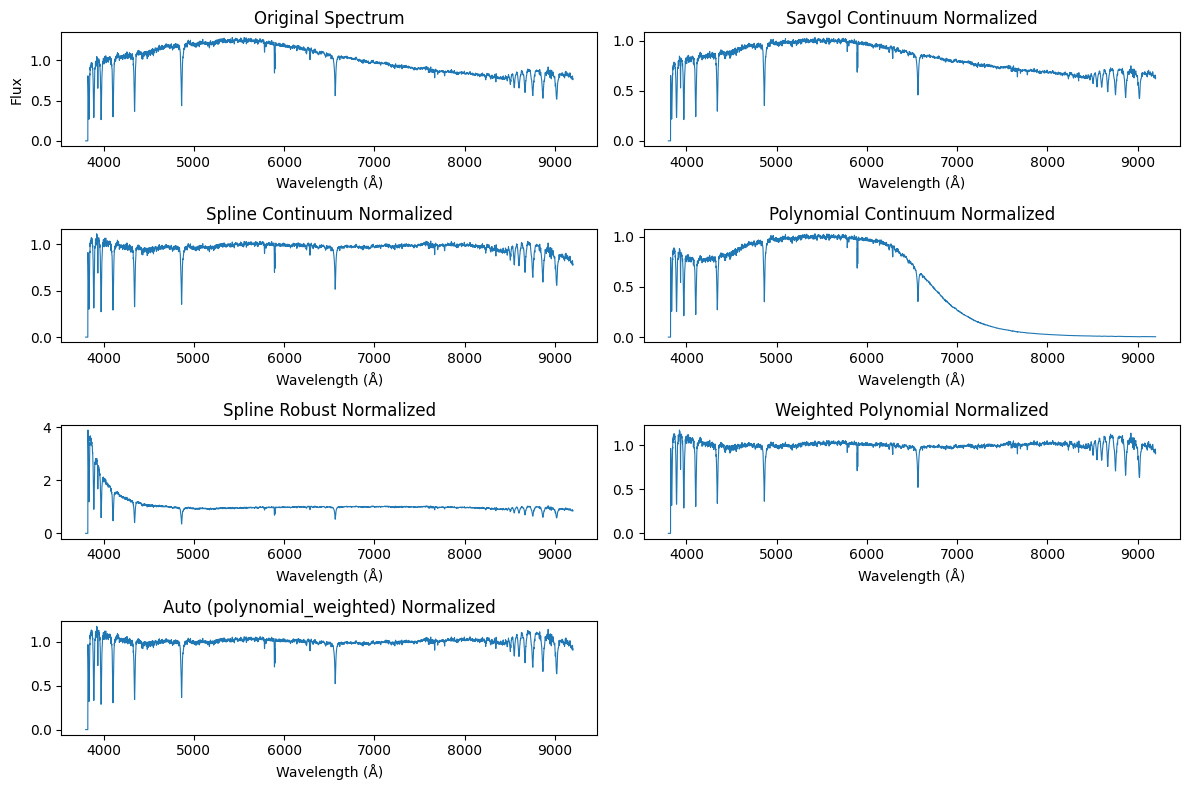

In [41]:
selected_keys = [ (5947, 56093, 30), (11060, 58523, 493), (4050, 55599, 14), (3794, 55241, 954), (1259, 52931, 638) ]

for s_key in selected_keys:
    spectrum, subclass, majorclass = fits_data[s_key]

    flux_savgol, cont_savgol = continuum_savgol(spectrum)
    flux_spline, cont_spline = continuum_spline(COMMON_WAVE, spectrum)
    flux_poly, cont_poly = continuum_polynomial(COMMON_WAVE, spectrum)

    flux_spline_wsavgol, cont_spline_wsavgol = continuum_spline_wsavgol(COMMON_WAVE, spectrum, verbose=True)
    flux_poly_weighted, cont_poly_weighted = continuum_polynomial_weighted(COMMON_WAVE, spectrum)

    flux_auto, cont_auto, method_used = auto_continuum_normalize(COMMON_WAVE, spectrum, verbose=True)


    plt.figure(figsize=(12, 8))

    plt.subplot(4, 2, 1)
    plt.plot(COMMON_WAVE, spectrum, label='Original', lw=0.8)
    plt.title("Original Spectrum")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")

    plt.subplot(4, 2, 2)
    plt.plot(COMMON_WAVE, flux_savgol, label='Savgol Filter', lw=0.8)
    plt.title("Savgol Continuum Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.subplot(4, 2, 3)
    plt.plot(COMMON_WAVE, flux_spline, label='Spline Fit', lw=0.8)
    plt.title("Spline Continuum Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.subplot(4, 2, 4)
    plt.plot(COMMON_WAVE, flux_poly, label='Polynomial Fit', lw=0.8)
    plt.title("Polynomial Continuum Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.subplot(4, 2, 5)
    plt.plot(COMMON_WAVE, flux_spline_wsavgol, label=f'Spline Robust fit', lw=0.8)
    # plt.plot(COMMON_WAVE, spectrum, label="Original")
    # plt.plot(COMMON_WAVE, cont_spline_wsavgol, label="Continuum")
    # plt.plot(COMMON_WAVE, flux_spline_wsavgol, label="Normalized", alpha=0.7)
    plt.title(f"Spline Robust Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.subplot(4, 2, 6)
    plt.plot(COMMON_WAVE, flux_poly_weighted, label=f'Weighted Polynomial fit', lw=0.8)
    plt.title(f"Weighted Polynomial Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.subplot(4, 2, 7)
    plt.plot(COMMON_WAVE, flux_auto, label=f'Auto ({method_used}) fit', lw=0.8)
    plt.title(f"Auto ({method_used}) Normalized")
    plt.xlabel("Wavelength (Å)")

    plt.tight_layout()
    plt.savefig(f"{data_output_dir}/plots/continuum_norm_{s_key}.png")
    # plt.show()

## Normalize

In [29]:
X, y, idx = [], [], []

for (plate, mjd, fiberID), (spectrum, subclass, majorclass) in fits_data.items():
    X.append(spectrum)
    y.append(majorclass)
    idx.append((plate, mjd, fiberID))

X = np.array(X)
y = np.array(y)

In [30]:
X_norm = []

for flux in X:
    flux_auto, cont_auto, method_used = auto_continuum_normalize(COMMON_WAVE, flux, verbose=False)
    X_norm.append(flux_auto)

X_norm = np.array(X_norm)



#### Inspect

In [31]:
def compute_flux_stats(spectra):
    stats = {
        'min_flux': np.min(spectra, axis=1),
        'max_flux': np.max(spectra, axis=1),
        'mean_flux': np.mean(spectra, axis=1),
        'median_flux': np.median(spectra, axis=1),
        'range_flux': np.ptp(spectra, axis=1),  # max - min
    }
    return pd.DataFrame(stats)

flux_stats_df = compute_flux_stats(X)
flux_stats_df_norm = compute_flux_stats(X_norm)

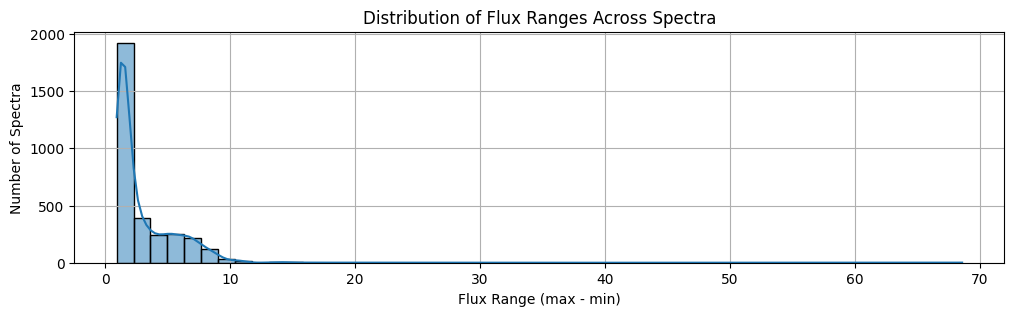

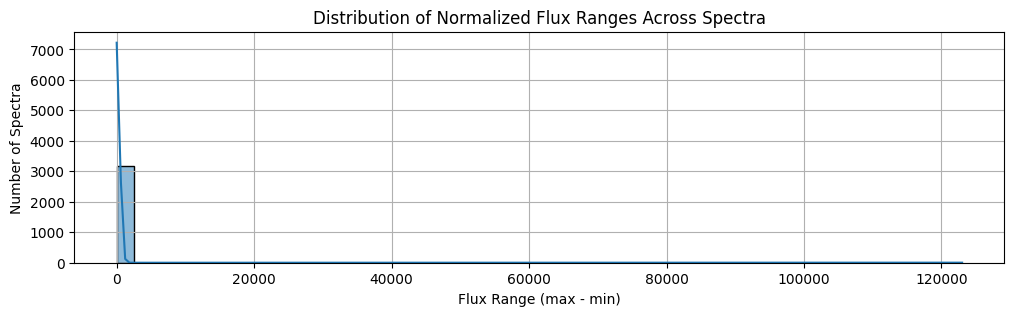

In [32]:
plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df['range_flux'], bins=50, kde=True)
plt.title("Distribution of Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df_norm['range_flux'], bins=50, kde=True)
plt.title("Distribution of Normalized Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

In [33]:
def plot_all_continuum_distributions(X_raw, wave, methods=None):
    if methods is None:
        methods = {
            "Savgol": lambda wave, flux: continuum_savgol(flux)[0],
            "Spline": lambda wave, flux: continuum_spline(wave, flux)[0],
            "Polynomial": lambda wave, flux: continuum_polynomial(wave, flux)[0],
            "Spline_WSavgol": lambda wave, flux: continuum_spline_wsavgol(wave, flux)[0],
            "Poly_Weighted": lambda wave, flux: continuum_polynomial_weighted(wave, flux)[0],
            "Auto": lambda wave, flux: auto_continuum_normalize(wave, flux, verbose=False)[0]
        }

    norm_data = {label: [] for label in methods}

    # Normalize each spectrum using all methods
    for flux in X_raw:
        for label, method_func in methods.items():
            try:
                norm_flux = method_func(wave, flux)
                norm_data[label].append(norm_flux)
            except Exception as e:
                print(f"{label} failed on a spectrum: {e}")
                continue

    # Compute flux range statistics
    plt.figure(figsize=(15, len(norm_data) * 2.5))
    for i, (label, spectra) in enumerate(norm_data.items(), 1):
        stats_df = compute_flux_stats(np.array(spectra))
        plt.subplot(len(norm_data), 1, i)
        sns.histplot(stats_df['range_flux'], bins=50, kde=True)
        plt.title(f"{label} - Flux Range Distribution")
        plt.xlabel("Flux Range (max - min)")
        plt.ylabel("Count")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


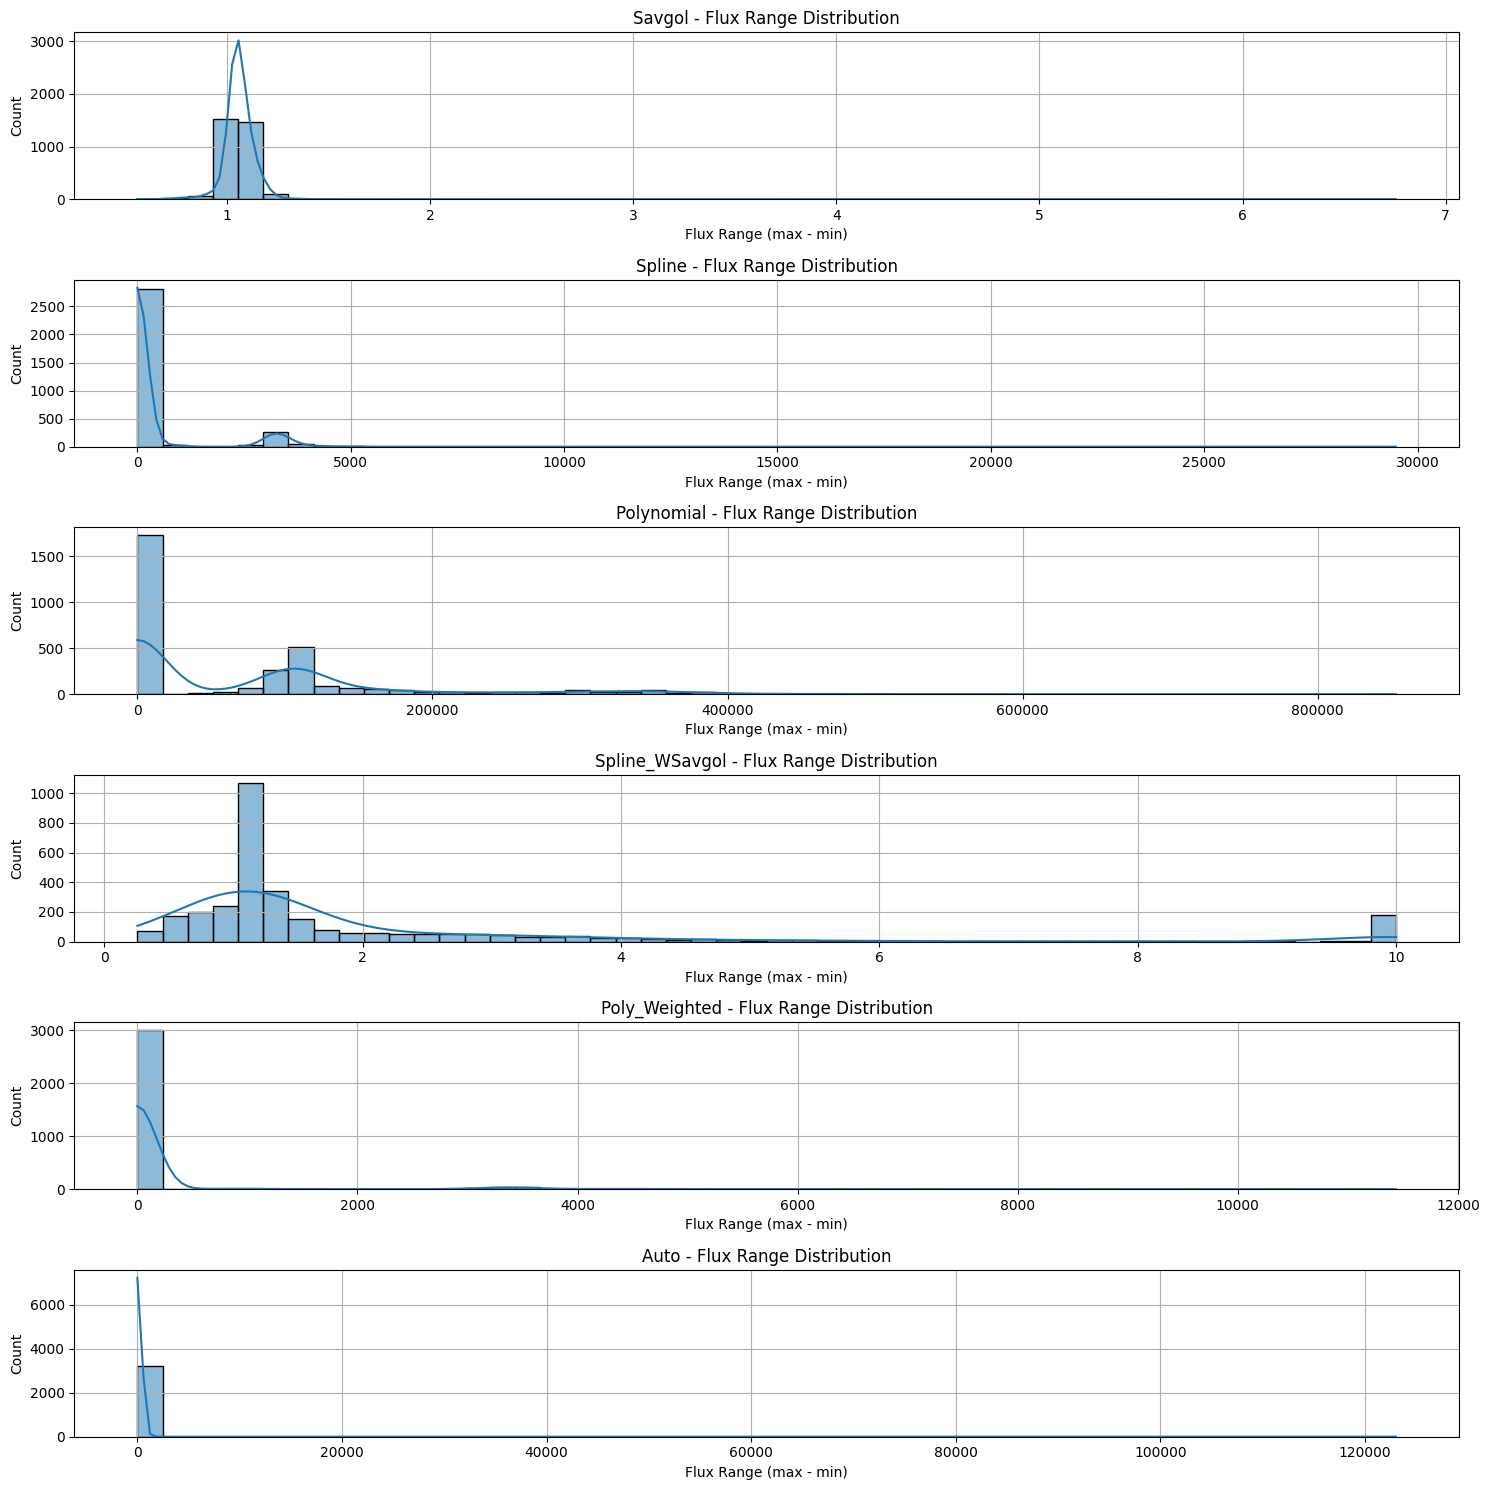

In [34]:
plot_all_continuum_distributions(X, COMMON_WAVE)